In [30]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from word2number import w2n

ModuleNotFoundError: No module named 'word2number'

In [2]:
df = pd.read_csv("hiring.csv")
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [6]:
df['test_score(out of 10)']

df.columns = ['experience', 'test_score', 'interview_score', 'salary']

In [8]:
df['test_score'] = df['test_score'].fillna(df['test_score'].mean())

df

,experience,test_score,interview_score,salary
0,NaN,8.000000,9,50000
1,NaN,8.000000,6,45000
2,five,6.000000,7,60000
3,two,10.000000,10,65000
4,seven,9.000000,6,70000
5,three,7.000000,10,62000
6,ten,7.857143,7,72000
7,eleven,7.000000,8,80000


In [9]:
word_to_num = {
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'seven': 7,
    'eight': 8,
    'nine': 9,
    'ten': 10,
    'eleven': 11
}

df['experience'] = df['experience'].map(word_to_num)

In [10]:
df['experience'] = df['experience'].fillna(df['experience'].median())

In [11]:
df

,experience,test_score,interview_score,salary
0,6.0,8.000000,9,50000
1,6.0,8.000000,6,45000
2,5.0,6.000000,7,60000
3,2.0,10.000000,10,65000
4,7.0,9.000000,6,70000
5,3.0,7.000000,10,62000
6,10.0,7.857143,7,72000
7,11.0,7.000000,8,80000


In [20]:
reg = linear_model.LinearRegression()
reg.fit(df[['experience']], df['salary'])

LinearRegression()

In [14]:
reg.coef_

array([2823.76559304, 1329.00027432, 2929.14459978])

In [15]:
reg.intercept_

11842.306307731189

In [ ]:
# 2 year experience, test score of 9, interview score of 6:

reg.predict([[2, 9, 6]]) 


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([47025.70756135])

In [17]:
2838.77 * 2 + 1329 * 9 + 2929.14 * 6 + 11842.306307731189

47055.686307731194

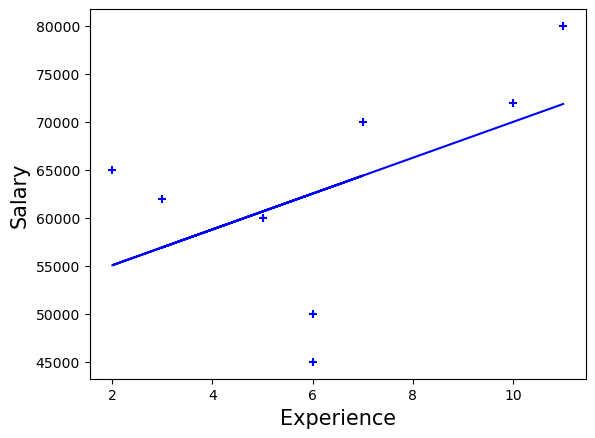

In [21]:
import matplotlib.pyplot as plt
plt.xlabel('Experience', fontsize = 15)
plt.ylabel('Salary', fontsize = 15)
plt.scatter(df.experience, df.salary, color = 'blue', marker = '+')
plt.plot(df.experience, reg.predict(df[['experience']]), color = 'blue')

In [23]:
reg = linear_model.LinearRegression()
reg.fit(df[['experience', 'test_score', 'interview_score']], df['salary'])

LinearRegression()

In [24]:
# 12 year experience, 10 test score, 10 interview score:

reg.predict([[12, 10, 10]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([88308.9421652])

In [25]:
reg.intercept_

11842.306307731189

In [26]:
reg.coef_

array([2823.76559304, 1329.00027432, 2929.14459978])

In [27]:
2823 * 12 + 1329 * 10 + 2929.14 * 10 + 11842.306307731189

88299.70630773119

In [28]:
reg.predict([[12, 10, 10]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([88308.9421652])

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- interview_score
- test_score


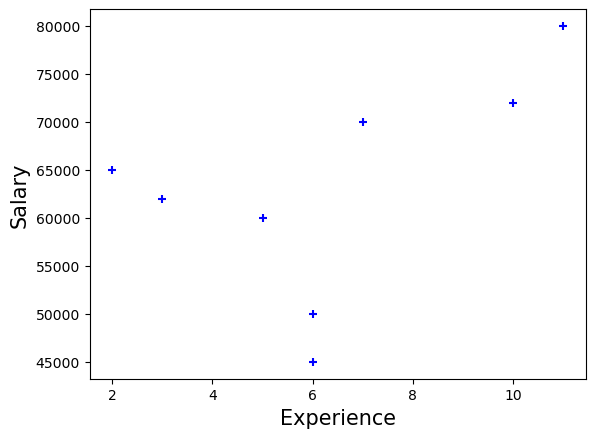

In [29]:
import matplotlib.pyplot as py
plt.xlabel('Experience', fontsize = 15)
plt.ylabel('Salary', fontsize = 15)
plt.scatter(df.experience, df.salary, color = 'blue', marker = '+')
plt.plot(df.experience, reg.predict(df[['experience']]), color = 'blue')